In [134]:
# Импорт стандартных библиотек и инструментов анализа
import json
from pathlib import Path
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [135]:
# Функции загрузки и преобразования структуры JSON в табличный формат

def load_experiment(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def extract_method_name(data: Dict[str, Any]) -> str:
    balancer = data["factors"]["balancer"]["name"]
    weights = data["factors"]["weights"]["name"]

    replication = data["factors"].get("replication", {})
    repl_strategy = replication.get("strategy", "none")

    completion = replication.get("completion", {})
    completion_strategy = completion.get("strategy", "none")

    return f"{balancer} | {repl_strategy} | {completion_strategy} | {weights}"


def flatten_requests(data: Dict[str, Any], method_name: str) -> pd.DataFrame:
    rows = []

    for wave in data["waves"]:
        wave_id = wave["wave_id"]
        makespan = wave["makespan_ms"]

        for req in wave["requests"]:
            signals = req.get("signals", {})
            upstream = req.get("upstream", {})
            response_json = req.get("response", {}).get("json", {})

            rows.append({
                "method": method_name,
                "wave_id": wave_id,
                "makespan_ms": makespan,
                "req_id": req["req_id"],
                "endpoint": req["endpoint"],
                "latency_ms": req["latency_ms"],
                "status": req["status"],
                "ok": req["ok"],
                "winner_socket": upstream.get("winner_socket"),
                "cpu_util": signals.get("cpu_util"),
                "mem_util": signals.get("mem_util"),
                "cpu_burn": signals.get("cpu_burn"),
                "mem_burn": signals.get("mem_burn"),
            })

    df = pd.DataFrame(rows)
    return df

In [136]:
# Указать директорию с JSON-файлами
DATA_DIR = Path("../experiments")

all_dfs = []

for file in DATA_DIR.glob("*.json"):
    data = load_experiment(file)
    method = extract_method_name(data)
    df = flatten_requests(data, method)
    all_dfs.append(df)

if len(all_dfs) < 2:
    raise ValueError("Для сравнений необходимо минимум 2 метода.")

df_all = pd.concat(all_dfs, ignore_index=True)

print("Загруженные методы:", df_all["method"].unique())

Загруженные методы: <StringArray>
[       'airm | hedged | first | entropy',
   'airm | speculative | first | entropy',
      'topsis | hedged | first | entropy',
 'topsis | speculative | first | entropy']
Length: 4, dtype: str


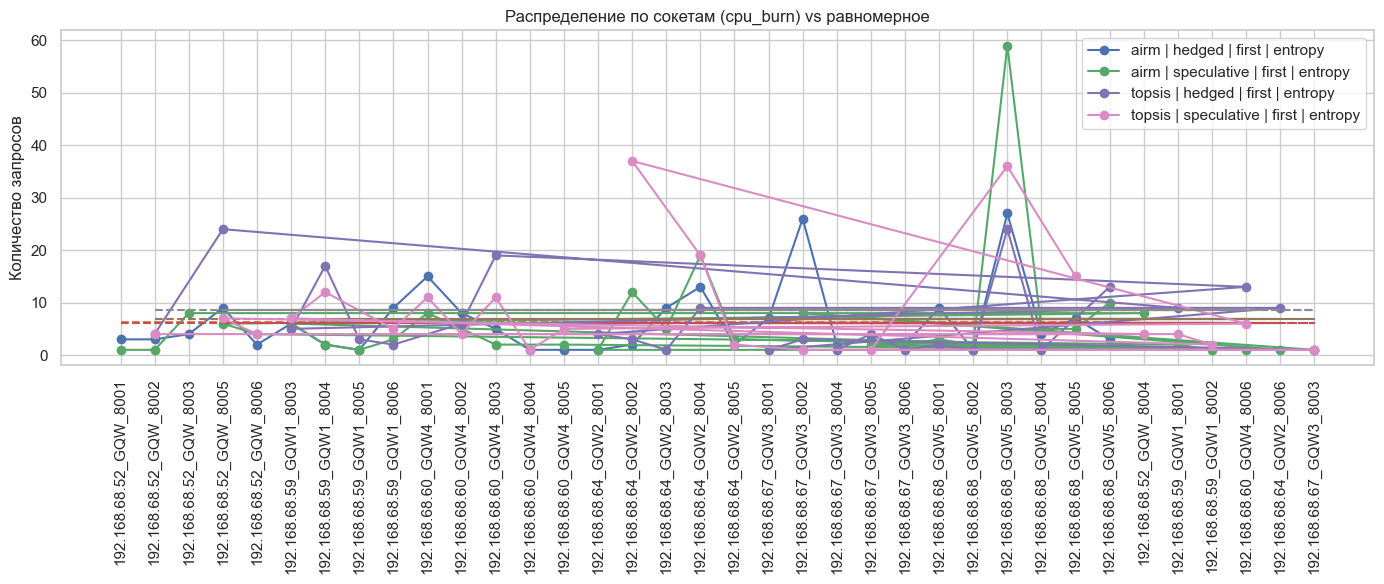

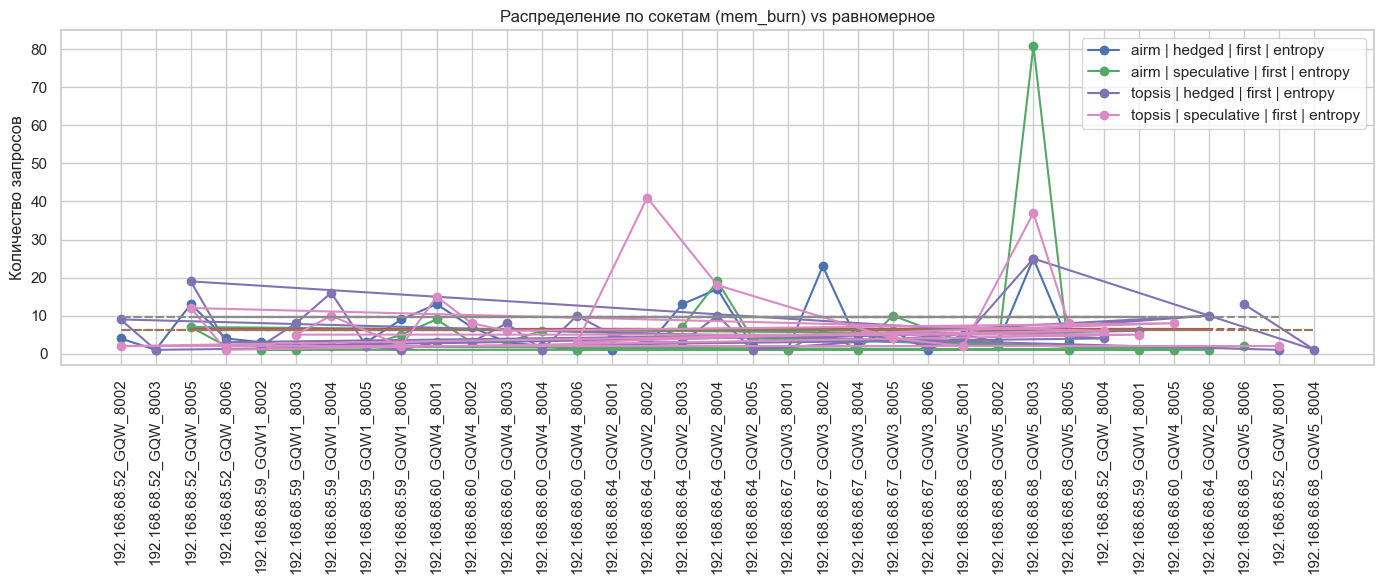

In [137]:
def plot_socket_distribution(df: pd.DataFrame, burn_type: str):
    """
    burn_type: 'cpu_burn' или 'mem_burn'
    """

    df_burn = df[df[burn_type] == True]

    distribution = (
        df_burn
        .groupby(["method", "winner_socket"])
        .size()
        .reset_index(name="count")
    )

    methods = distribution["method"].unique()

    plt.figure(figsize=(14, 6))

    for method in methods:
        sub = distribution[distribution["method"] == method]
        sockets = sub["winner_socket"]
        counts = sub["count"]

        uniform = np.ones(len(counts)) * counts.sum() / len(counts)

        plt.plot(sockets, counts, marker="o", label=f"{method}")
        plt.plot(sockets, uniform, linestyle="--")

    plt.xticks(rotation=90)
    plt.title(f"Распределение по сокетам ({burn_type}) vs равномерное")
    plt.ylabel("Количество запросов")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_socket_distribution(df_all, "cpu_burn")
plot_socket_distribution(df_all, "mem_burn")

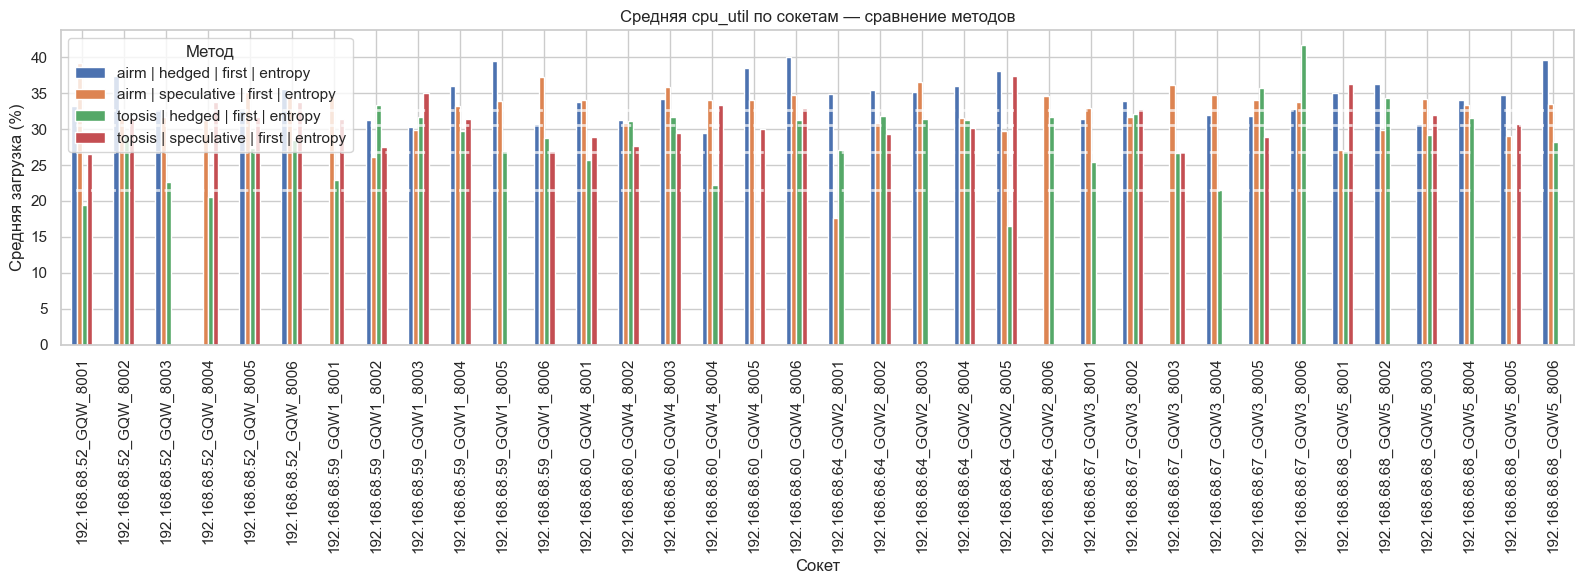

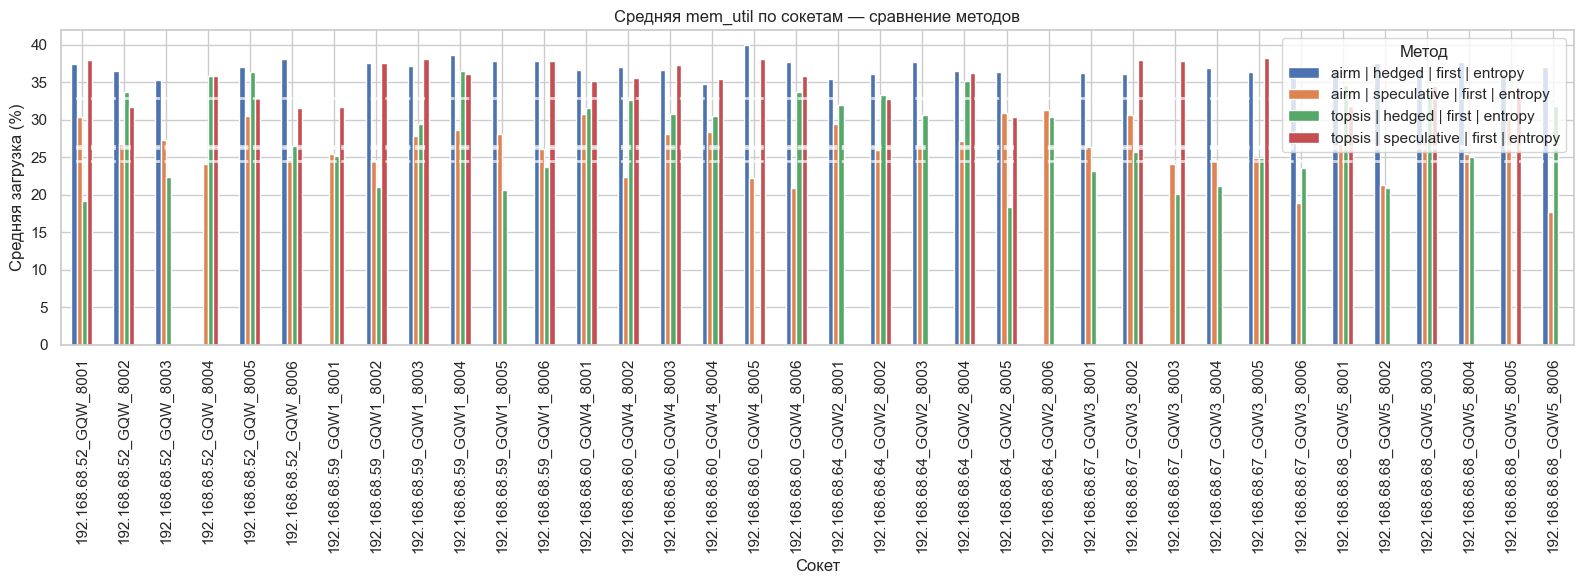

In [144]:
def plot_util_distribution(df: pd.DataFrame, util_col: str):
    """
    Корректное сравнительное распределение средней загрузки по сокетам
    с унифицированной осью и аккуратной визуализацией.
    """

    df_util = df[df[util_col].notna()].copy()

    # Агрегация
    agg = (
        df_util
        .groupby(["method", "winner_socket"])[util_col]
        .mean()
        .reset_index()
    )

    # Унифицированный список сокетов
    all_sockets = sorted(agg["winner_socket"].unique())

    # Pivot-таблица (методы × сокеты)
    pivot = (
        agg
        .pivot(index="winner_socket", columns="method", values=util_col)
        .reindex(all_sockets)
        .fillna(0)
    )

    # Равномерная линия (среднее по каждому методу)
    uniform_lines = pivot.mean(axis=0)

    # Построение
    ax = pivot.plot(kind="bar", figsize=(16, 6))

    # Добавление равномерных линий
    for i, method in enumerate(pivot.columns):
        ax.axhline(
            uniform_lines[method],
            linestyle="--",
            linewidth=2,
            alpha=0.7
        )

    plt.title(f"Средняя {util_col} по сокетам — сравнение методов")
    plt.ylabel("Средняя загрузка (%)")
    plt.xlabel("Сокет")
    plt.xticks(rotation=90)
    plt.legend(title="Метод")
    plt.tight_layout()
    plt.show()


plot_util_distribution(df_all, "cpu_util")
plot_util_distribution(df_all, "mem_util")

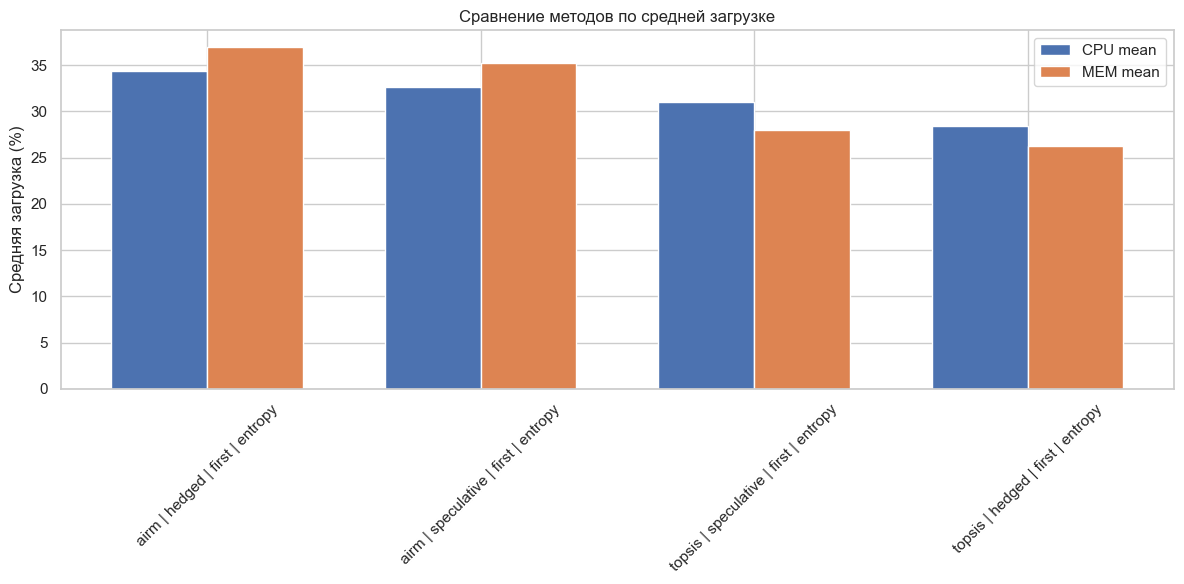

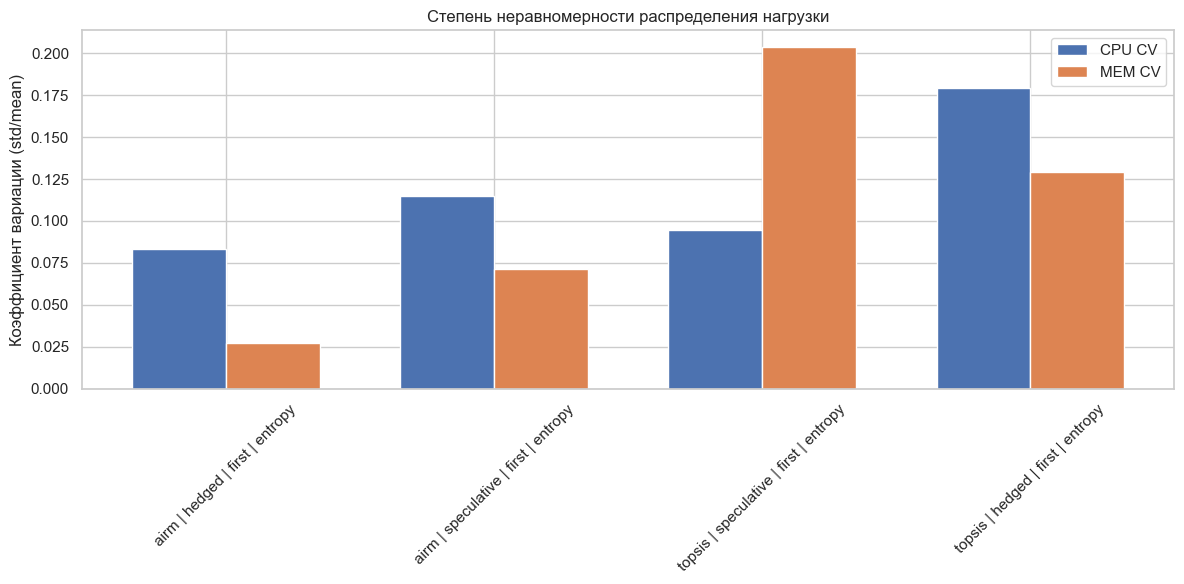

In [146]:
def aggregate_util_by_method(df: pd.DataFrame, util_col: str) -> pd.DataFrame:
    """
    Агрегирует метрики загрузки по МЕТОДУ (не по сокету).
    Возвращает таблицу с описательной статистикой.
    """

    df_util = df[df[util_col].notna()].copy()

    # Сначала считаем среднюю загрузку на каждом сокете
    socket_level = (
        df_util
        .groupby(["method", "winner_socket"])[util_col]
        .mean()
        .reset_index()
    )

    # Теперь агрегируем по методам
    method_level = (
        socket_level
        .groupby("method")[util_col]
        .agg(
            mean="mean",
            std="std",
            min="min",
            max="max",
            socket_count="count"
        )
    )

    # Коэффициент вариации — мера неравномерности
    method_level["cv"] = method_level["std"] / method_level["mean"]

    return method_level.sort_values("mean", ascending=False)


def plot_method_level_util(cpu_stats: pd.DataFrame, mem_stats: pd.DataFrame):
    """
    Сравнение методов по агрегированной загрузке CPU и MEM.
    """

    methods = cpu_stats.index

    x = np.arange(len(methods))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(x - width / 2, cpu_stats["mean"], width, label="CPU mean")
    ax.bar(x + width / 2, mem_stats["mean"], width, label="MEM mean")

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45)
    ax.set_ylabel("Средняя загрузка (%)")
    ax.set_title("Сравнение методов по средней загрузке")
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_variability(cpu_stats: pd.DataFrame, mem_stats: pd.DataFrame):
    """
    Сравнение коэффициента вариации (степени разбалансировки).
    """

    methods = cpu_stats.index
    x = np.arange(len(methods))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(x - width / 2, cpu_stats["cv"], width, label="CPU CV")
    ax.bar(x + width / 2, mem_stats["cv"], width, label="MEM CV")

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45)
    ax.set_ylabel("Коэффициент вариации (std/mean)")
    ax.set_title("Степень неравномерности распределения нагрузки")
    ax.legend()

    plt.tight_layout()
    plt.show()


cpu_method_stats = aggregate_util_by_method(df_all, "cpu_util")
mem_method_stats = aggregate_util_by_method(df_all, "mem_util")

plot_method_level_util(cpu_method_stats, mem_method_stats)
plot_variability(cpu_method_stats, mem_method_stats)

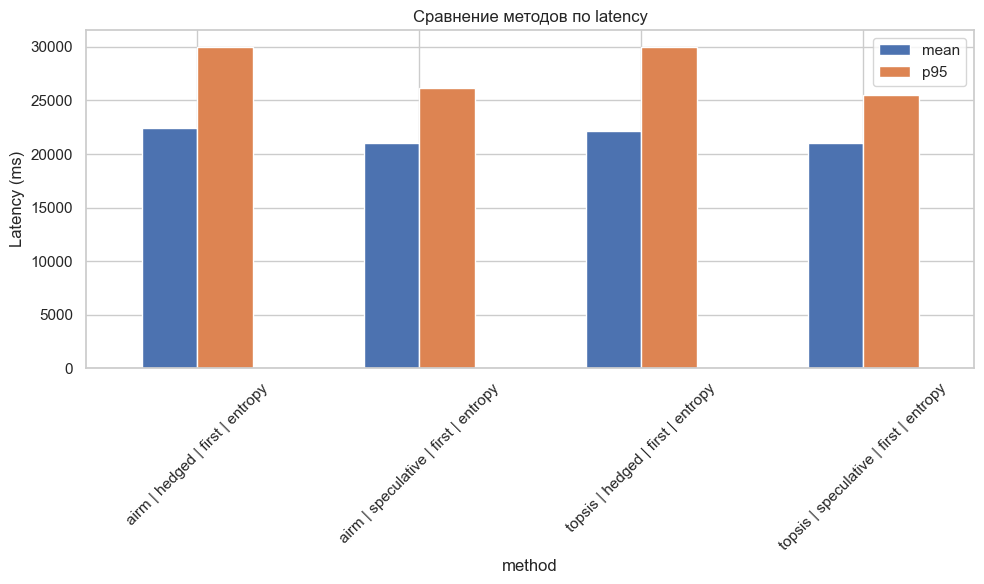

In [139]:
latency_stats = (
    df_all
    .groupby("method")["latency_ms"]
    .agg(["mean", lambda x: np.percentile(x, 95)])
    .rename(columns={"<lambda_0>": "p95"})
)

latency_stats.plot(kind="bar", figsize=(10, 6))
plt.title("Сравнение методов по latency")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

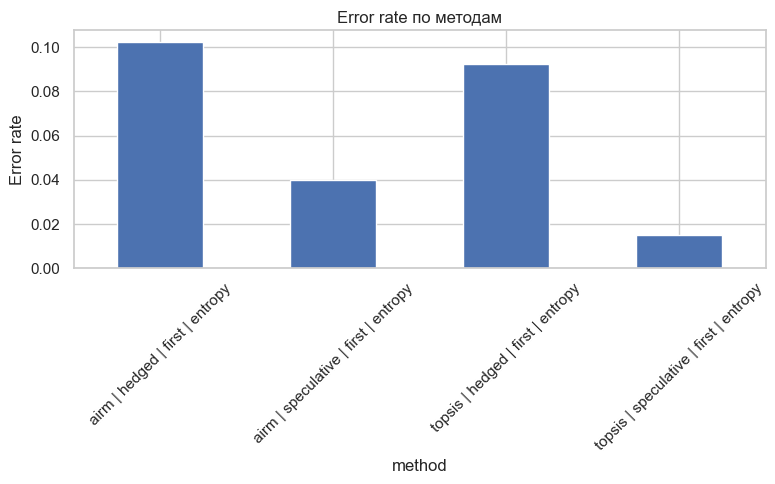

In [140]:
error_stats = (
    df_all
    .groupby("method")["ok"]
    .apply(lambda x: 1 - x.mean())
)

error_stats.plot(kind="bar", figsize=(8, 5))
plt.title("Error rate по методам")
plt.ylabel("Error rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

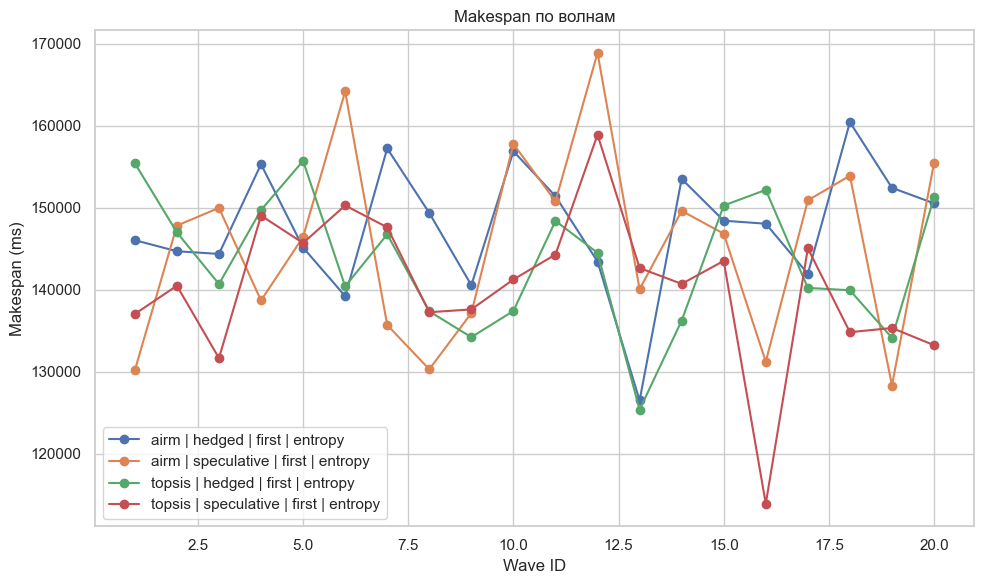

In [141]:
makespan = (
    df_all
    .groupby(["method", "wave_id"])["makespan_ms"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for method in makespan["method"].unique():
    sub = makespan[makespan["method"] == method]
    plt.plot(sub["wave_id"], sub["makespan_ms"], marker="o", label=method)

plt.title("Makespan по волнам")
plt.xlabel("Wave ID")
plt.ylabel("Makespan (ms)")
plt.legend()
plt.tight_layout()
plt.show()

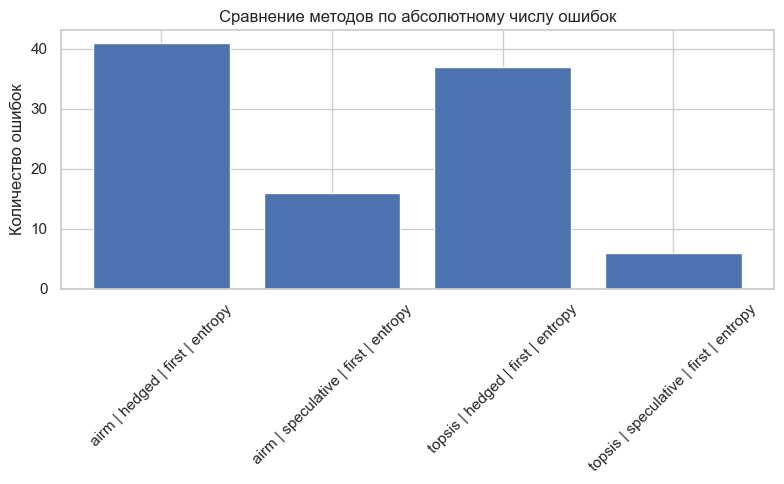

In [142]:
# Абсолютное число ошибок и общее число запросов
error_summary = (
    df_all
    .groupby("method")
    .agg(
        total_requests=("req_id", "count"),
        total_errors=("ok", lambda x: (~x).sum())
    )
)

error_summary["error_rate"] = error_summary["total_errors"] / error_summary["total_requests"]
# Столбчатое сравнение количества ошибок

plt.figure(figsize=(8, 5))

plt.bar(error_summary.index, error_summary["total_errors"])
plt.ylabel("Количество ошибок")
plt.title("Сравнение методов по абсолютному числу ошибок")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

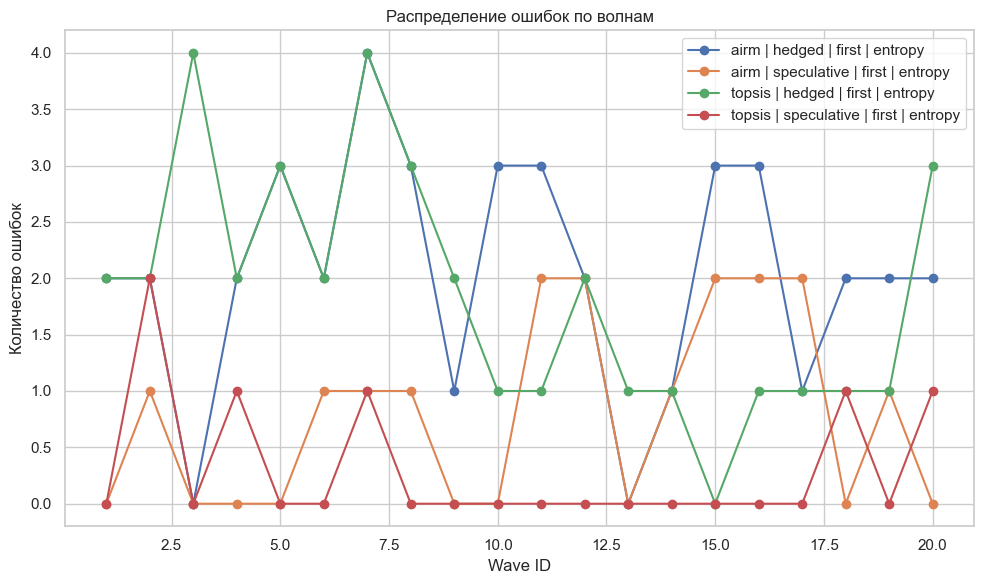

In [143]:
# Подсчёт ошибок по волнам
errors_by_wave = (
    df_all
    .assign(error=lambda x: ~x["ok"])
    .groupby(["method", "wave_id"])["error"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for method in errors_by_wave["method"].unique():
    sub = errors_by_wave[errors_by_wave["method"] == method]
    plt.plot(sub["wave_id"], sub["error"], marker="o", label=method)

plt.xlabel("Wave ID")
plt.ylabel("Количество ошибок")
plt.title("Распределение ошибок по волнам")
plt.legend()
plt.tight_layout()
plt.show()